In [ ]:
'''Step-1)Loading The data'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\waldi\Downloads\US_Accidents.csv")

In [ ]:
'''Step-2) Understanding the data'''
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


Step-3) Cleaning the Data

In [8]:
df.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [9]:
df = df.dropna(subset=['Weather_Condition'])

Converting Time Column

In [11]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

Extracting Features

In [12]:
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.day_name()
df['Month'] = df['Start_Time'].dt.month_name()

#ANALYZING ACCIDENT PATTERNS
A.Questions:
Which hour has most accidents?
Rush hour effect?

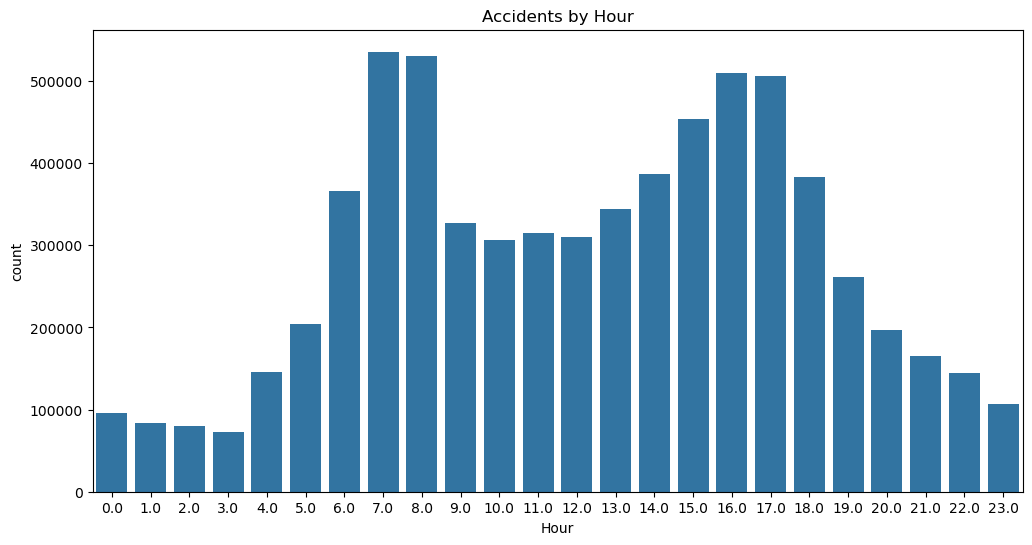

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(x='Hour', data=df)
plt.title("Accidents by Hour")
plt.show()

B. Accidents by Weather
Questions:

More accidents in rain?
Fog impact?
Snow impact?

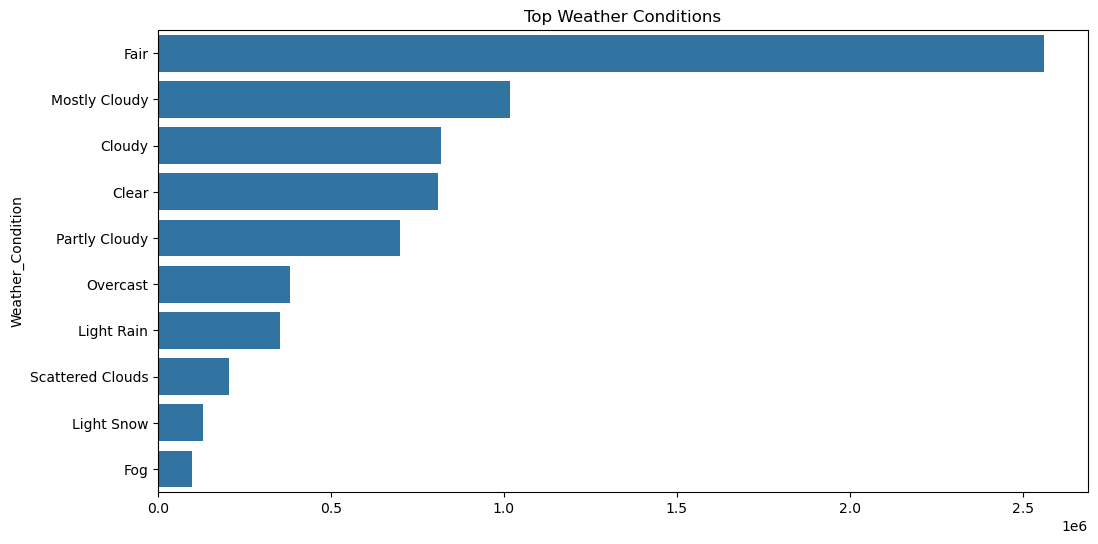

In [14]:
top_weather = df['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_weather.values, y=top_weather.index)
plt.title("Top Weather Conditions")
plt.show()

C. Day vs Night

<Axes: xlabel='Sunrise_Sunset', ylabel='count'>

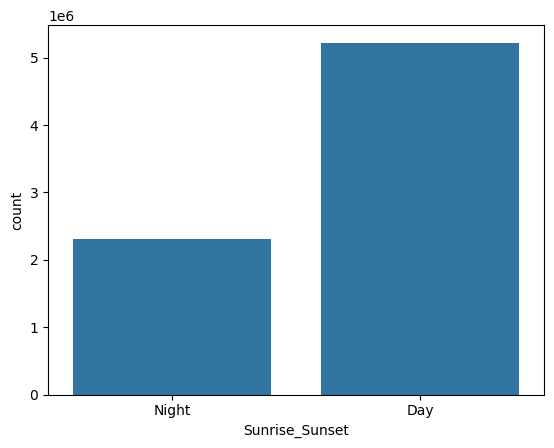

In [15]:
sns.countplot(x='Sunrise_Sunset', data=df)

D. Severity Analysis
Which conditions lead to severe crashes?

<Axes: xlabel='Severity', ylabel='count'>

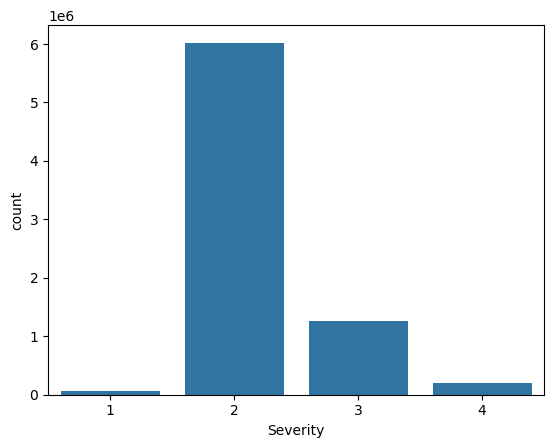

In [16]:
sns.countplot(x='Severity', data=df)

E. Road Condition Factors

Columns like:

Junction
Traffic_Signal
Crossing
Stop
Railway

Questions:

Are intersections accident hotspots?
Do traffic signals reduce severity?

In [17]:
road_features = ['Junction', 'Traffic_Signal', 'Crossing']

for col in road_features:
    print(df.groupby(col)['Severity'].mean())

Junction
False    2.204527
True     2.297730
Name: Severity, dtype: float64
Traffic_Signal
False    2.232856
True     2.088754
Name: Severity, dtype: float64
Crossing
False    2.230395
True     2.063822
Name: Severity, dtype: float64


6. Identify Accident Hotspots

This is one of the most important parts.
1. Scatter Map

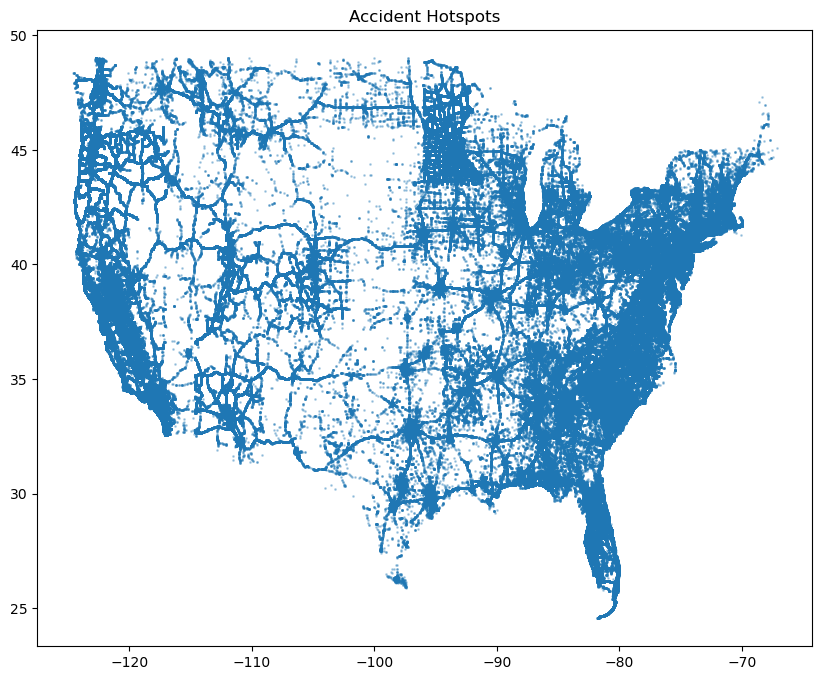

In [18]:
plt.figure(figsize=(10,8))
plt.scatter(df['Start_Lng'], df['Start_Lat'],
            s=1, alpha=0.3)
plt.title("Accident Hotspots")
plt.show()

2.Interactive Heatmap with Folium

In [19]:
import folium
from folium.plugins import HeatMap

sample_df = df.sample(10000)

m = folium.Map(location=[39.5, -98.35], zoom_start=4)

heat_data = list(zip(sample_df['Start_Lat'],
                     sample_df['Start_Lng']))

HeatMap(heat_data).add_to(m)

m.save("accident_heatmap.html")

7. Correlation Analysis

Checking numeric relationships:

<Axes: >

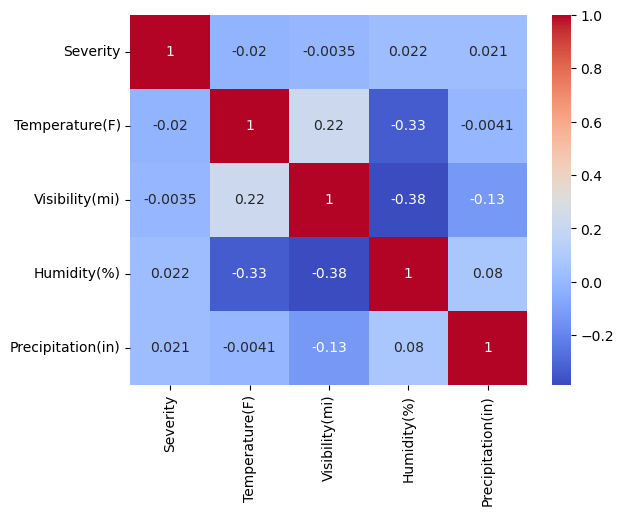

In [20]:
corr = df[['Severity',
           'Temperature(F)',
           'Visibility(mi)',
           'Humidity(%)',
           'Precipitation(in)']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')